In [1]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 423.7 kB/s eta 0:00:03
   ------------ --------------------------- 0.5/1.7 MB 423.7 kB/s eta 0:00:03
   ------------ --------------------------- 0.5/1.7 MB 423.7 kB/s eta 0:00:03
   ------------ --------------------------- 0.5/1.7 MB 423.7 kB/s eta 0:00:03
   ------------------ --------------------- 0.8/1.7 MB 351.1 kB/s eta 0:00:03
   ------------------ --------------------- 0.8/1.7 MB 351.1 kB/s eta 0:00:03
   ------------------ --------------------- 0.8/1.7 MB 351.1 kB/s eta 0:00:03
   ------------------------- -----------

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

In [5]:
now = datetime.now()

In [6]:
start = datetime(now.year-10, now.month, now.day)

In [7]:
end = now

In [22]:
ticker = 'AAPL'

In [23]:
df = yf.download(ticker, start, end)

[*********************100%***********************]  1 of 1 completed


In [24]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
2016-05-25,22.678457,22.705774,22.334706,22.462189,152675200
2016-05-26,22.858295,22.931143,22.455355,22.692110,225324800
2016-05-27,22.844641,22.871959,22.594226,22.637480,145364800
2016-05-31,22.733093,22.856024,22.496337,22.673904,169228800
2016-06-01,22.414385,22.660247,22.384791,22.541868,116693200
...,...,...,...,...,...
2026-05-18,297.839996,300.660004,294.910004,300.239990,34483000
2026-05-19,298.970001,300.510010,296.350006,296.970001,42243600
2026-05-20,302.250000,302.799988,298.079987,298.179993,38229800


In [11]:
df.shape

(2513, 5)

In [25]:
df = df.reset_index()

In [26]:
plt.figure(figsize=(12,9))

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

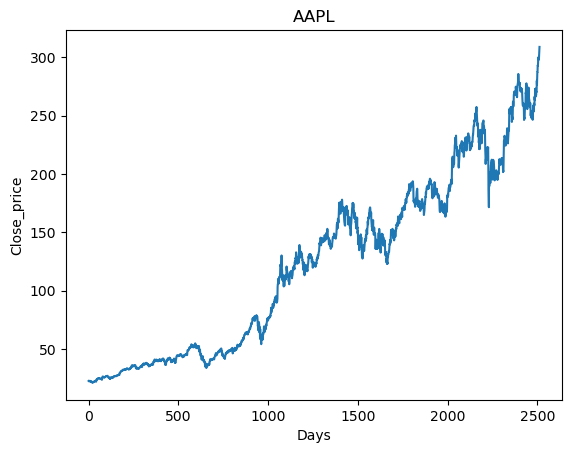

In [28]:
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close_price');

In [29]:
df

Price,index,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-05-25,22.678457,22.705774,22.334706,22.462189,152675200
1,2016-05-26,22.858295,22.931143,22.455355,22.692110,225324800
2,2016-05-27,22.844641,22.871959,22.594226,22.637480,145364800
3,2016-05-31,22.733093,22.856024,22.496337,22.673904,169228800
4,2016-06-01,22.414385,22.660247,22.384791,22.541868,116693200
...,...,...,...,...,...,...
2508,2026-05-18,297.839996,300.660004,294.910004,300.239990,34483000
2509,2026-05-19,298.970001,300.510010,296.350006,296.970001,42243600
2510,2026-05-20,302.250000,302.799988,298.079987,298.179993,38229800


In [30]:
df

Price,index,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-05-25,22.678457,22.705774,22.334706,22.462189,152675200
1,2016-05-26,22.858295,22.931143,22.455355,22.692110,225324800
2,2016-05-27,22.844641,22.871959,22.594226,22.637480,145364800
3,2016-05-31,22.733093,22.856024,22.496337,22.673904,169228800
4,2016-06-01,22.414385,22.660247,22.384791,22.541868,116693200
...,...,...,...,...,...,...
2508,2026-05-18,297.839996,300.660004,294.910004,300.239990,34483000
2509,2026-05-19,298.970001,300.510010,296.350006,296.970001,42243600
2510,2026-05-20,302.250000,302.799988,298.079987,298.179993,38229800


In [31]:
df['MA_100'] = df.Close.rolling(100).mean()

In [32]:
df

Price,index,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-05-25,22.678457,22.705774,22.334706,22.462189,152675200,NaN
1,2016-05-26,22.858295,22.931143,22.455355,22.692110,225324800,NaN
2,2016-05-27,22.844641,22.871959,22.594226,22.637480,145364800,NaN
3,2016-05-31,22.733093,22.856024,22.496337,22.673904,169228800,NaN
4,2016-06-01,22.414385,22.660247,22.384791,22.541868,116693200,NaN
...,...,...,...,...,...,...,...
2508,2026-05-18,297.839996,300.660004,294.910004,300.239990,34483000,265.337966
2509,2026-05-19,298.970001,300.510010,296.350006,296.970001,42243600,265.609117
2510,2026-05-20,302.250000,302.799988,298.079987,298.179993,38229800,265.898595


Text(0.5, 1.0, 'Moving Average')

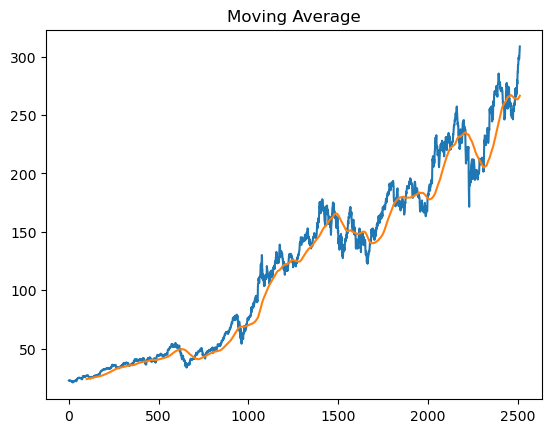

In [33]:
plt.plot(df.Close)
plt.plot(df.MA_100)
plt.title("Moving Average")

In [34]:
df['Percentage_Change'] = df.Close.pct_change()

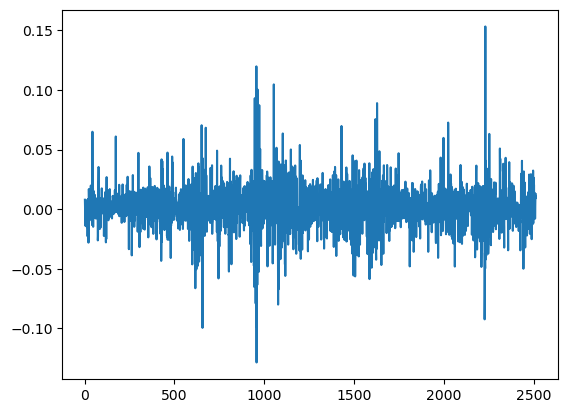

In [35]:
plt.plot(df.Percentage_Change)

In [3]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

In [4]:
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])
scaler = MinMaxScaler(feature_range=(0,1))
dt_array = scaler.fit_transform()

NameError: name 'df' is not defined